## Setup

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 72
from IPython.display import display
import numpy as np
from scipy.sparse import lil_matrix
import pandas as pd

MOVIE_DATA_CSV= '../../datasets/movie_data.csv'

In [2]:
df = pd.DataFrame()
df = pd.read_csv(MOVIE_DATA_CSV)    

# Sanity
print(f'#rows={len(df)} #columns={len(df.columns)}')
df.head()

#rows=50000 #columns=2


,review,sentiment
0,"In 1974, the teenager Martha Moxley (Maggie Gr...",1
1,OK... so... I really like Kris Kristofferson a...,0
2,"***SPOILER*** Do not read this, if you think a...",0
3,hi for all the people who have seen this wonde...,1
4,"I recently bought the DVD, forgetting just how...",0


In [3]:
Reviews = [_ for _ in df.review if _ != 'Unknown']

# sanity
print(len(Reviews))
print(Reviews[0:3])

50000
['In 1974, the teenager Martha Moxley (Maggie Grace) moves to the high-class area of Belle Haven, Greenwich, Connecticut. On the Mischief Night, eve of Halloween, she was murdered in the backyard of her house and her murder remained unsolved. Twenty-two years later, the writer Mark Fuhrman (Christopher Meloni), who is a former LA detective that has fallen in disgrace for perjury in O.J. Simpson trial and moved to Idaho, decides to investigate the case with his partner Stephen Weeks (Andrew Mitchell) with the purpose of writing a book. The locals squirm and do not welcome them, but with the support of the retired detective Steve Carroll (Robert Forster) that was in charge of the investigation in the 70\'s, they discover the criminal and a net of power and money to cover the murder.<br /><br />"Murder in Greenwich" is a good TV movie, with the true story of a murder of a fifteen years old girl that was committed by a wealthy teenager whose mother was a Kennedy. The powerful and ric

In [4]:
Sentiments = [_ for _ in df.sentiment if _ != 'Unknown']

# sanity
print(len(Sentiments))
print(Sentiments[0:3])


50000
[1, 0, 0]


In [5]:
class Markov:  # Uses a sparse matrix to handle probabilities
    def __init__(self, order=1):
        self.voc, self.vocindex, self.vocindexrev = None, None, None
        self.conds, self.condsindex, self.condsindexrev = None, None, None
        self.Pjoint = None  # Joint probabilities
        self.Pvoc = None  # marginal P for vocabulary
        self.Pconds = None  # marginal P for conditionings
        self.Pconditional = None  # Conditional probabilities, Markov model
        self.order = order

    def get_vocabulary(self, _toks):  # input as list of tokens, 1-gram
        voc = set()
        for _ in _toks:
            voc.update(_)
        self.voc = sorted(voc)
        self.vocindex = {v:i for i, v in enumerate(self.voc)}
        self.vocindexrev = {i:v for i, v in enumerate(self.voc)}
    
    def get_conds(self, _toks):  # conditioning events, n-1-gram
        conds = set()
        for tok in _toks:
            for i in range(len(tok)-self.order):  # boundary condition
                cond = " ".join(tok[i:i+self.order])
                conds.update([cond])
        self.conds = sorted(conds)
        self.condsindex = {cond:i for i, cond in enumerate(self.conds)}
        self.condsindexrev = {i:cond for i, cond in enumerate(self.conds)}
    
    def get_counts(self, _toks):  # build the P
        M, N = len(self.vocindex), len(self.condsindex)
        pc = lil_matrix((N,M), dtype=np.float32)
        # pc = np.zeros((N,M), dtype=np.float32)
        for tok in _toks:
            for i in range(len(tok)-self.order-1):  # boundary condition
                cond = " ".join(tok[i:i+self.order])
                voc = tok[i+self.order]
                i, j = self.condsindex[cond], self.vocindex[voc]
                pc[i,j] += 1
        return pc

    def fit(self, _toks):
        self.get_vocabulary(_toks)
        self.get_conds(_toks)
        pc = self.get_counts(_toks)
        # joint P, make it into probabilities
        self.Pjoint = pc / np.sum(pc)
        # marginal P for vocabulary and conds
        self.Pvoc = np.array(np.sum(self.Pjoint,axis=0)).squeeze()
        self.Pconds = np.array(np.sum(self.Pjoint,axis=1)).squeeze()
        # conditional P
        sm = np.array(pc.sum(axis=1)).squeeze()
        sm[sm==0] = 1  # handle divide by zero
        self.Pconditional = lil_matrix(pc / sm[:,None])
        # sanity
        print(f'Size of vocabulary={len(self.voc)}, N={len(self.conds)}, Pjoint.shape={self.Pjoint.shape}')
        return self

In [6]:
# These are needed for stopwords
from nltk import regexp_tokenize
from nltk.corpus import stopwords
import nltk

import re

HTML_TAGS = [
    r'<\s*br\s*/?\s*>',
    r'<\s*/?\s*i\s*>',
    r'<\s*/?\s*em\s*>',
]

def strip_known_html(text):
    for pat in HTML_TAGS:
        text = re.sub(pat, ' ', text, flags=re.IGNORECASE)
    return text

# from the sklearn API the default token_pattern='(?u)\\b\\w\\w+\\b'
TOKEN_PATTERN= r'(?u)\b[a-zA-Z]\w+\b'

nltk.download("punkt")
nltk.download("punkt_tab")

nltk.download('stopwords')

STOP_WORDS = set(stopwords.words('english'))

tokens_by_sentiment = {0: [], 1: []}

def clean_and_tokenize_review(review: str) -> list[str]:
    text = strip_known_html(review)
    tokens = regexp_tokenize(text.lower(), TOKEN_PATTERN)  
    tokens = [t for t in tokens if t not in STOP_WORDS]
    return tokens

for review, sentiment in zip(Reviews, Sentiments):
    toks = clean_and_tokenize_review(review)
    if len(toks) == 0:
        continue  # skip empty reviews after filtering
    tokens_by_sentiment[int(sentiment)].append(toks)
    
markov0_2 = Markov(order=2).fit(tokens_by_sentiment[0])
markov1_2 = Markov(order=2).fit(tokens_by_sentiment[1])

[nltk_data] Downloading package punkt to /Users/jeff/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/jeff/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/jeff/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Size of vocabulary=71539, N=1656161, Pjoint.shape=(1656161, 71539)
Size of vocabulary=74531, N=1769230, Pjoint.shape=(1769230, 74531)


## Problem 1

The following code uses the order 2 model to generate 3 sequential words starting with the context "worst movie" and keeps track of the probability of each word and each sequence as it's formed.

For Sentiment 2, the default logic outputs "movie" as the third word. As such, the code optionally allows prior words to be skipped and the next most probable word to be used.

In [7]:
def getwords(_model, _w):
    i1 = _model.condsindex[_w]
    arr = _model.Pconditional[i1,:].toarray().squeeze()  # argsort will not work on lil_matrix
    ix = np.argsort(arr)[::-1]
    return [(_model.vocindexrev[ix[_]], _model.Pconditional[_model.condsindex[_w],ix[_]]) for _ in range(10)]

def getnextword(_model, _w1, _w2, prior_words=None):
    SEQ = f"{_w1} {_w2}"
    result = getwords(_model, SEQ)
    
    # If prior_words is provided, skip words that already appear
    if prior_words is not None:
        prior_words_set = set(prior_words)
        for word, prob in result:
            if word not in prior_words_set:
                return word, prob

    # No prior_words provided
    return result[0][0], result[0][1]

def generatewords(_model, skippriorwords = False):
    words = ['worst', 'movie']
    probabilities = [1,1]

    # Generate 3 words
    for _ in range(3):
        nextword, prob = getnextword(_model, words[-2], words[-1], prior_words=words if skippriorwords else None)
        words.append(nextword)
        probabilities.append(prob)

    cumulative_prob = 1.0  
    for i, word in enumerate(words):
            # Update cumulative probability by multiplying with the conditional probability
            cumulative_prob *= probabilities[i]
            print(f"{i+1}. {word} (P={probabilities[i]:.5f}, P_seq={cumulative_prob:.5f})")

    sequence_prob = np.prod(probabilities) if len(probabilities) > 0 else 1.0
    sequence_text = " ".join(words)

    print(f"\nSequence: '{sequence_text}'")
    print(f"Sequence probability: {sequence_prob:.10f}")

print(f"Sentiment 0")
print("=" * 50)
generatewords(markov0_2)

print(f"\nSentiment 1")
print("=" * 50)
generatewords(markov1_2)

print(f"\nSentiment 1 - skip prior words")
print("=" * 50)
generatewords(markov1_2, True)



Sentiment 0
1. worst (P=1.00000, P_seq=1.00000)
2. movie (P=1.00000, P_seq=1.00000)
3. ever (P=0.63857, P_seq=0.63857)
4. seen (P=0.46371, P_seq=0.29611)
5. life (P=0.04142, P_seq=0.01226)

Sequence: 'worst movie ever seen life'
Sequence probability: 0.0122640633

Sentiment 1
1. worst (P=1.00000, P_seq=1.00000)
2. movie (P=1.00000, P_seq=1.00000)
3. ever (P=0.55556, P_seq=0.55556)
4. seen (P=0.36963, P_seq=0.20535)
5. movie (P=0.03433, P_seq=0.00705)

Sequence: 'worst movie ever seen movie'
Sequence probability: 0.0070505971

Sentiment 1 - skip prior words
1. worst (P=1.00000, P_seq=1.00000)
2. movie (P=1.00000, P_seq=1.00000)
3. ever (P=0.55556, P_seq=0.55556)
4. seen (P=0.36963, P_seq=0.20535)
5. film (P=0.03112, P_seq=0.00639)

Sequence: 'worst movie ever seen film'
Sequence probability: 0.0063896037


### Sentiment 0 
The next three words are 'ever seen life.' The probability of this sequence being generated is about 1.2%. 

The probability of each word and each sequence is shown below. The sequence probability is calculated by multiplying the probabilities of the prior words with the current word.

| Order | Word | Prob of word | Prob of sequence | 
|---|-------------|------|---------|
|1 | ever | 63.9% | 63.9% | 
|2 | seen | 46.3% | 29.6% |
|3 | life | 4.1% | 1.2% |

### Sentiment 1 
The next three words are 'ever seen movie.' The probability of this sequence being generated is about 0.7%. 

The probability of each word and each sequence is shown below. The sequence probability is calculated by multiplying the probabilities of the prior words with the current word.

| Order | Word | Prob of word | Prob of sequence | 
|---|-------------|------|---------|
|1 | ever | 55.6% | 55.6% | 
|2 | seen | 37.0% | 20.5% |
|3 | movie | 3.4% | 0.7% |

#### Sentiment 1 - if we don't repeat 'movie'
If we don't allow 'movie' because it duplicates a prior word and choose the next most probable word instead, we have:

| Order | Word | Prob of word | Prob of sequence | 
|---|-------------|------|---------|
|1 | ever | 55.6% | 55.6% | 
|2 | seen | 37.0% | 20.5% |
|3 | film | 3.1% | 0.6% |

## Problem 2

### Valid Distribution
To show this defines a valid probability distribution, we have to show:

1. All probabilities are non-negative
2. The sum of the probabilities is 1

Clearly, 0.5, 0.3, and 0.2 are non-negative. 

Further, $0.5+0.3+0.2=1$, so we conclude this is a valid probability distribution.

### Probability Calculation
Since the events are independent, the probability is

$$
    P(\text{``AI model future''})=P(\text{``model"} \mid \text{``AI"}) \times P(\text{``future"} \mid \text{``model"}).
$$

We are not given $P(\text{``future"} \mid \text{``model"})$ in the problem, so we assume the distribution stays the same regardless of context and use 0.2. Hence,

$$
    P(\text{``AI model future''})=0.5 \times 0.2 = 0.1.
$$

### Probability Distributions Central to Text Generation
Probability distributions allow generative models to represent uncertainty and variability in language, enabling them to sample diverse text rather than producing a single deterministic output. Text generation is fundamentally a probabilistic process because there are multiple valid ways to continue any given phrase/context.


## Problem 3

| Distribution | Type | Support | Mean | Variance | Skewness | Kurtosis | Typical Application |
|-------------|------|---------|------|----------|----------|----------|---------------------|
| Gaussian $N(\mu,\sigma^2)$ | Continuous | $(-\infty,\infty)$ | $\mu$ | $\sigma^2$ | $0$ | $0$ | Measurement noise, heights, errors |
| Exponential $Exp(\lambda)$ | Continuous | $x \ge 0$ | $\frac{1}{\lambda}$ | $\frac{1}{\lambda^2}$ | $2$ | $6$ | Waiting times, memoryless processes |
| Uniform $Unif(a,b)$| Continuous | $a \le x \le b$ | $\frac{(a+b)}{2}$ | $\frac{(b-a)^2}{12}$ | $0$ | $-\frac{6}{5}$ | Random sampling with no preference |
| Beta $Beta(\alpha,\beta)$| Continuous | $0 \le x \le 1$ | $\frac{\alpha}{(\alpha+\beta)}$ | $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$ | varies | varies | Probabilities, Bayesian priors |
| Gamma $Gamma(k,\theta)$| Continuous | $x \ge 0$ | $k\theta$ | $k\theta^2$ | $\frac{2}{\sqrt{k}}$ | $\frac{6}{k}$ | Waiting times, reliability modeling |
| Poisson $Pois(\lambda)$ | Discrete | $\{0,1,2,\dots\}$ | $\lambda$ | $\lambda$ | $\frac{1}{\sqrt{\lambda}}$ | $\frac{1}{\lambda}$ | Event counts in fixed intervals |
| Binomial $Bin(n,p)$ | Discrete | $\{0,1,\dots,n\}$ | $np$ | $np(1-p)$ | $\frac{1-2p}{\sqrt{np(1-p)}}$ | $\frac{1-6p(1-p)}{np(1-p)}$ | Number of successes in $n$ trials |

### References
Grinstead, C. M., & Snell, J. L. (2012). Chapter 5: Conditional probability. In *Introduction to probability* (2nd ed.). American Mathematical Society. Retrieved from Johns Hopkins University Library.

Larsen, R. J., & Marx, M. L. (2018). *An introduction to mathematical statistics and its applications* (6th ed.). Pearson.





## Problem 4

To represent adult male height, we use a normal distribution with a mean of 69 inches and standard deviation of 3 inches. These numbers come from the CDC site referenced below (the standard deviation is estimated based on the 95th and 5th percentile numbers). 

We round the heights because people rarely measure their height beyond a tenth of an inch.

### Reference
Centers for Disease Control and Prevention. (2018). *Anthropometric reference data for children and adults: United States, 2015–2018*. National Center for Health Statistics. https://www.cdc.gov/nchs/data/series/sr_03/sr03-046-508.pdf


In [8]:
import numpy as np

np.random.seed(42)

mu = 69    
sigma = 3  
n = 10     

heights = np.random.normal(loc=mu, scale=sigma, size=n)

heights = np.round(heights[:n], 1)
print(heights)

[70.5 68.6 70.9 73.6 68.3 68.3 73.7 71.3 67.6 70.6]


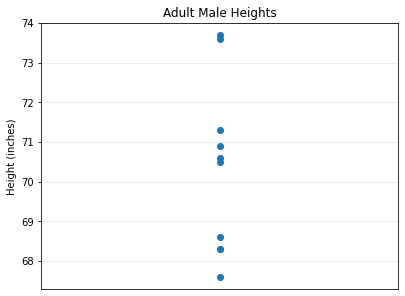

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(np.ones(len(heights)), heights)
plt.xticks([])
plt.ylabel("Height (inches)")
plt.title("Adult Male Heights")
plt.grid(True, axis='y', alpha=0.3)
plt.show()

## Problem 5

### Setup

In [10]:
import pmdarima as pm

In [11]:
# get the dataset
df = pd.read_csv('../../datasets/PJME_hourly.csv', parse_dates=[0])  # parse dates
df = df.sort_values(by='Datetime').set_index('Datetime')

# sanity
display(df.head())
print(f'#rows= {len(df)}')

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


#rows= 145366


The code below picks an arbitrary date in the data set and sets the training period 7 days (168 hours) before that date and the test period 12 hours after that date.

In [12]:
t0 = pd.Timestamp('2016-02-01 00:00:00')   

train_hours = 7 * 24   # 168 hours
horizon = 12           # 12 hours

train_start = t0 - pd.Timedelta(hours=train_hours)
train_end   = t0
test_end    = t0 + pd.Timedelta(hours=horizon)

df_train = df.loc[train_start:train_end - pd.Timedelta(hours=1), 'PJME_MW'].copy()
df_test = df.loc[t0:test_end - pd.Timedelta(hours=1), 'PJME_MW'].copy()

# sanity
print(len(df_train), len(df_test))

168 12


We find the best ARIMA model parameters

In [13]:
%%time

# Automatically find the best ARIMA model parameters
model = pm.auto_arima(df_train, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)

# Print the best model parameters
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2794.434, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2862.013, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2817.911, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2823.340, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2860.083, Time=0.00 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2807.532, Time=0.12 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2819.053, Time=0.18 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2819.554, Time=0.09 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=2815.106, Time=0.16 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2806.172, Time=0.16 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=2763.723, Time=0.22 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=2765.852, Time=0.24 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept   : AIC=i

Use the model to forecast and plot the original data and the forecast.

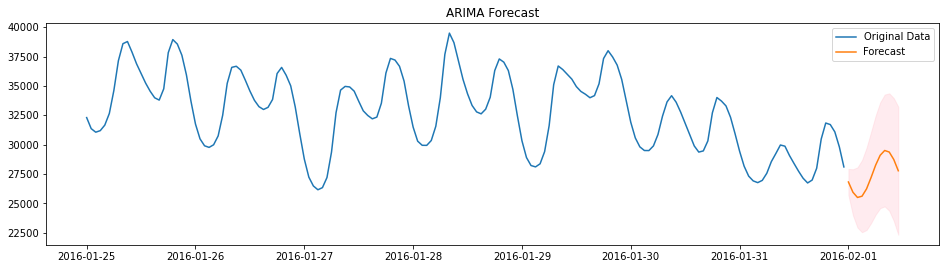

In [14]:
# Forecast the next periods
forecast, conf_int = model.predict(n_periods=horizon, return_conf_int=True)

forecast_index = pd.date_range(t0, periods=horizon, freq='h')

# Plot the original data and the forecast
_, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 4))
ax.plot(df_train, label='Original Data')
plt.plot(forecast_index, forecast, label='Forecast')
plt.fill_between(forecast_index, conf_int[:,0], conf_int[:,1], color='pink', alpha=0.3)
plt.legend()
plt.title('ARIMA Forecast')
plt.show()

Compute the mean squared error and the mean absolute percentage for the forecast.

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

mse = mean_squared_error(df_test.values, forecast)
print(f'MSE= {mse:,.0f}')

mape = mean_absolute_percentage_error(df_test.values, forecast)
print(f'MAPE= {mape:.5f}')

MSE= 4,571,371
MAPE= 0.06518


## Problem 6 [Separate Project Work]

Below are the problem descriptions and ideal solutions in the GenAI field for the three topics I listed earlier.

### 1. Solver Log Copilot

#### Problem description
Modern MIP/LP solvers (e.g., Gurobi, CPLEX, HiGHS) generate long, unstructured logs containing presolve statistics, heuristic activity, branching behavior, cut generation, and numerical warnings. Interpreting these logs to diagnose why a solve was slow or unsuccessful requires deep solver expertise and significant manual effort.

#### Ideal solution
A generative AI system that ingests raw solver logs and produces:

- Structured summaries of solver phases (presolve, root relaxation, branch-and-bound, heuristics)
- Natural-language diagnostics identifying likely bottlenecks (e.g., degeneracy, weak relaxations, excessive node growth)
- Actionable recommendations such as parameter tuning, alternative heuristics, or model reformulation suggestions

Such a system would function as an “AI copilot” for optimization practitioners.

### 2. Cut and Heuristic Generator for MILP

#### Problem description
The performance of MILP solvers depends heavily on the availability of effective cutting planes, primal heuristics, and good warm starts. Designing these components is highly problem-specific and traditionally requires expert knowledge..

#### Ideal solution
A generative model trained on historical solve data that can:

- Propose candidate cutting planes or cut families based on problem structure
- Suggest primal heuristics for constructing feasible solutions
- Generate warm starts by identifying patterns from previously solved, similar instances

The system would augment traditional solvers by dynamically suggesting solver choices that reduce solve time.

### 3. Natural Language MIP Generator

#### Problem description
Real-world optimization problems are often specified in natural language (e.g., scheduling, resource allocation, logistics). Translating these descriptions into correct and efficient mixed-integer programs is error-prone and requires specialized mathematical expertise.

#### Ideal solution
A generative AI system that:

- Takes a natural-language problem description as input
- Extracts decision variables, constraints, and objective functions
- Produces a structured MIP formulation
- Outputs both human-readable LaTeX and solver-ready files (e.g., LP or MPS)

This would lower the barrier to entry for optimization modeling and reduce formulation errors.

## Research Topic - Solver Log Copilot

### Problem Description
Modern MIP/LP solvers (e.g., Gurobi, CPLEX, HiGHS) generate long, unstructured logs containing presolve statistics, heuristic activity, branching behavior, cut generation, and numerical warnings. Interpreting these logs to diagnose why a solve was slow or unsuccessful requires deep solver expertise and significant manual effort.

### Data Set
The dataset consists of solver log files generated from solving linear and mixed-integer optimization problems using standard solvers.

- Raw text logs from MILP and LP solvers (e.g., Rose, SCIP, Gurobi, HiGHS, CPLEX-style logs). (I'll probably pick one solver to focus on).
- Logs include timestamps, presolve summaries, node statistics, cut counts, heuristic activity, and termination status
- Expert-annotated diagnoses (e.g., “stalling due to degeneracy,” “poor presolve,” “weak root relaxation”)
- Solver performance outcomes (solve time, node count, gap progression)


### Performance Metrics

The Solver Log Copilot will be evaluated on its ability to produce useful and accurate diagnostic output.

The main metric will be diagnosis accuracy as measured by agreement between the model’s predicted bottleneck category and expert labels.